<a href="https://colab.research.google.com/github/DeeDom50/Python/blob/main/EET207-Applied-Engineering-Programming/week5/DataProcessing_ImageProcessing_CourseProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image and Data Processing Course Project
### Answer the questions and download your completed activity with full outputs as a .pynb and a .pdf file. Use the Print option in the web browser to download the .pdf file. In your Chrome browser, press CTRL+P and select Set the Destination to "Save as PDF" or "Print to PDF" or the apropriate selection based on your computer. Save the file and submit your .pdf file in Canvas. A video on this process can be viewed using this [link](https://ecpi.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=2c60ba53-b182-4dd2-ba40-b12901260d39) or by running the code block below this. Thanks!

In [ ]:
# Download Colab Notebook as .pdf and .ipynb Instructions

from IPython.display import HTML

HTML("""
<iframe src="https://ecpi.hosted.panopto.com/Panopto/Pages/Embed.aspx?id=2c60ba53-b182-4dd2-ba40-b12901260d39&autoplay=false&offerviewer=true&showtitle=true&showbrand=true&captions=false&interactivity=all"
height="950" width="1950" style="border: 1px solid #464646;" allowfullscreen allow="autoplay" aria-label="Panopto Embedded Video Player"></iframe>
""")

Run this code first to mount your Google drive so you can access the files in your drive

Accept prompt and sign in to drive and wait for the console to say
'Mounted at /content/drive'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Part I Data Processing

### For the first section of this project, you will use the csv library to read Atmosphere Temperature, Soil Temperature, Atmosphere Humidity and Soil Humidity from Plant_Data.csv. Don't forget to close your file at the end!
> 1. Create a function to read each variable into a dictionary using the csv.DictReader() function
2. Inside of that same function, use a for loop to append each of the value pairs for each category to an empty list
3. Pass these lists to another function that will calculate the averages if the values in each list (Hint: Make sure your data is the correct data type)
4. Use the function to return these averages to the main(). Display the 4 average values inside main() with 2 digit precision.

In [1]:
import csv
from statistics import mean

def read_to_list():

  with open('/content/Plant_Data_OG.csv') as csvfile:
    # create dictionary with key value pairs
    reader = csv.DictReader(csvfile)

    # create empty lists
    atm_temp_avg = []
    soil_temp_avg = []
    atm_hum_avg = []
    soil_hum_avg = []

    # append each value from dictionary to list
    for i in reader:
      atm_temp_avg.append(float(i['Atmosphere Temp']))
      soil_temp_avg.append(float(i['Soil Temperature']))
      atm_hum_avg.append(float(i['Atmosphere Humidity']))
      soil_hum_avg.append(float(i['Soil Humidity']))

  return atm_temp_avg, soil_temp_avg, atm_hum_avg, soil_hum_avg


def calc_avgs(a_t, s_t, a_h, s_h):

  average_atm_temp = 0
  average_soil_temp = 0
  average_atm_hum = 0
  average_soil_hum = 0

  for j in a_t:
    average_atm_temp += j
  average_atm_temp /= len(a_t)

  for j in s_t:
    average_soil_temp += j
  average_soil_temp /= len(s_t)

  for j in a_h:
    average_atm_hum += j
  average_atm_hum /= len(a_h)

  for j in s_h:
    average_soil_hum += j
  average_soil_hum /= len(s_h)

  return average_atm_temp, average_soil_temp, average_atm_hum, average_soil_hum


# Main function
def main():

  atm_temp, soil_temp, atm_hum, soil_hum = read_to_list()

  avg_atm_temp, avg_soil_temp, avg_atm_hum, avg_soil_hum = calc_avgs(
      atm_temp, soil_temp, atm_hum, soil_hum
  )

  print(f'Average Atmosphere Temperature: {avg_atm_temp:.2f}')
  print(f'Average Soil Temperature: {avg_soil_temp:.2f}')
  print(f'Average Atmosphere Humidity: {avg_atm_hum:.2f}')
  print(f'Average Soil Humidity: {avg_soil_hum:.2f}')


# call main to kick it off
main()

Average Atmosphere Temperature: 80.07
Average Soil Temperature: 75.69
Average Atmosphere Humidity: 25.81
Average Soil Humidity: 96.91


### For the section part of this project. You will find the two data sets that have the highest correlation (either negitive or positive) and then plot the data using a scatter plot. Then using the seaborn library, plot the regression line of the data.
#### The necessary libraries have already been imported for you. You should review these resources to better understand correlation, regression and the seaborn library.

> 1. [Correlation Coefficient | Types, Formulas & Examples](https://www.scribbr.com/statistics/correlation-coefficient/)
2. [NumPy, SciPy, and pandas: Correlation With Python](https://realpython.com/numpy-scipy-pandas-correlation-python/)
3. [Visualizing statistical relationships](https://seaborn.pydata.org/tutorial/relational.html#relating-variables-with-scatter-plots)
4. [Estimating Regression Fits](https://seaborn.pydata.org/tutorial/regression.html)
5. [Regression Line Object](https://seaborn.pydata.org/generated/seaborn.regplot.html#seaborn.regplot)
6. [The seaborn.objects Interface](https://seaborn.pydata.org/tutorial/objects_interface.html)


1. Create a function to read each colmn of Atmosphere Temperature, Soil Temperature, Atmosphere Humidity and Soil Humidity using the .values method from the numpy library.
2. Pass the .values to a second function that will calculate and display the correlation coefficient of the two highest correlation values to the console. Choose any correlation method you wish. Good examples can be found in the second resrouce listed above. (there will be one negative and one positive correlation)
*** *(HINT: You may need to test different combinations to get the best correlations. i.e. Atm Hum vs Soil Hum, Atm Temp vs Soil Hum...etc.)* ***
3. Pass the .values to a third function that will display a 2 scatter plots of the two data sets with a properly fit regression line. Label the plots with the appropriate title and label the x-axis and y-axis as well. Display the plots to the console and also include code to save the file to Plant_Corr.pdf.
*** *(HINT: The seaborn library has a very good regplot function that you may want to look at...)* ***
4. Create the main() function which calls all three functions. Don't forget to call main to kick it off!

		Positive Correlation: 93%
		Negative Correlation: -52%


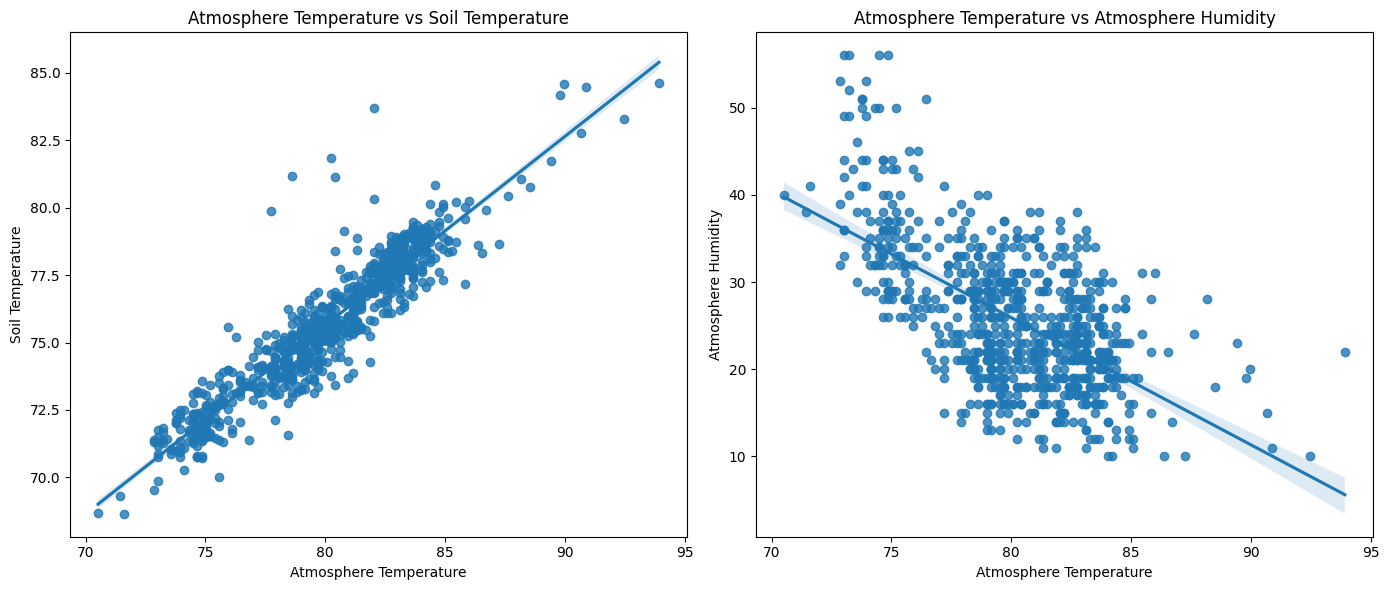

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import spearmanr as spr
import seaborn as sns

def read_to_values():

  plant_file = pd.read_csv('/content/Plant_Data_OG.csv')

  atm_temp = plant_file['Atmosphere Temp'].values
  soil_temp = plant_file['Soil Temperature'].values
  atm_hum = plant_file['Atmosphere Humidity'].values
  soil_hum = plant_file['Soil Humidity'].values

  return atm_temp, soil_temp, atm_hum, soil_hum


def corr_calc(atm_temp, soil_temp, atm_hum, soil_hum):

  # strongest positive correlation
  result, p_value = spr(atm_temp, soil_temp)

  # strongest negative correlation
  result2, p_value2 = spr(atm_temp, atm_hum)

  print(f"\t\tPositive Correlation: {result:.0%}")
  print(f"\t\tNegative Correlation: {result2:.0%}")


def plot_me(atm_temp, soil_temp, atm_hum, soil_hum):

  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # Positive correlation
  sns.regplot(
      x=atm_temp,
      y=soil_temp,
      ax=axes[0]
  )

  axes[0].set_title('Atmosphere Temperature vs Soil Temperature')
  axes[0].set_xlabel('Atmosphere Temperature')
  axes[0].set_ylabel('Soil Temperature')

  # Negative correlation
  sns.regplot(
      x=atm_temp,
      y=atm_hum,
      ax=axes[1]
  )

  axes[1].set_title('Atmosphere Temperature vs Atmosphere Humidity')
  axes[1].set_xlabel('Atmosphere Temperature')
  axes[1].set_ylabel('Atmosphere Humidity')

  plt.tight_layout()

  plt.savefig('/content/Plant_Corr.pdf')

  plt.show()


def main():

  atm_temp, soil_temp, atm_hum, soil_hum = read_to_values()

  corr_calc(atm_temp, soil_temp, atm_hum, soil_hum)

  plot_me(atm_temp, soil_temp, atm_hum, soil_hum)


main()

---
---

# Part II
# Image Processing

## Detecting Images Using Color
####Remember how the guided adjusted image clarity using the blur method?  There are other ways to play with different elements in images to find things that might be missed on first glance. This code goes hunting for red objects, like red tomatoes.
####Instead of looking at red, green and blue values directly, the code uses a special color code called HSV. This code makes it easier to pick out specific colors.  By setting a range for "red", the code can find all the pixels that fall within that range.  Think of it like sifting through a bag of skittles looking for the good ones(the red ones ;).
####Once the red skittles are identified, the code creates a "spotlight" that highlights only the red areas. The spotlight outlines the shapes of the red objects in the picture.  By adjusting the settings, we can fine-tune what the code finds, like searching for green skittles instead of red ones.
####This techniques alone can be applied as simply as using red, yellow and green lights to monitor traffic flow or as specific as separating tissue and blood vessels in medical scans based on their color variations. It's like making your computer your sixth sense!
---
##***Download the Tomatoes_Ripe.jpg file from the assignment page.***
---
####Run the code below a few times and play with some of the variable values and see what happens to the output! When you have a good idea of how the program works, complete the final part of this project.

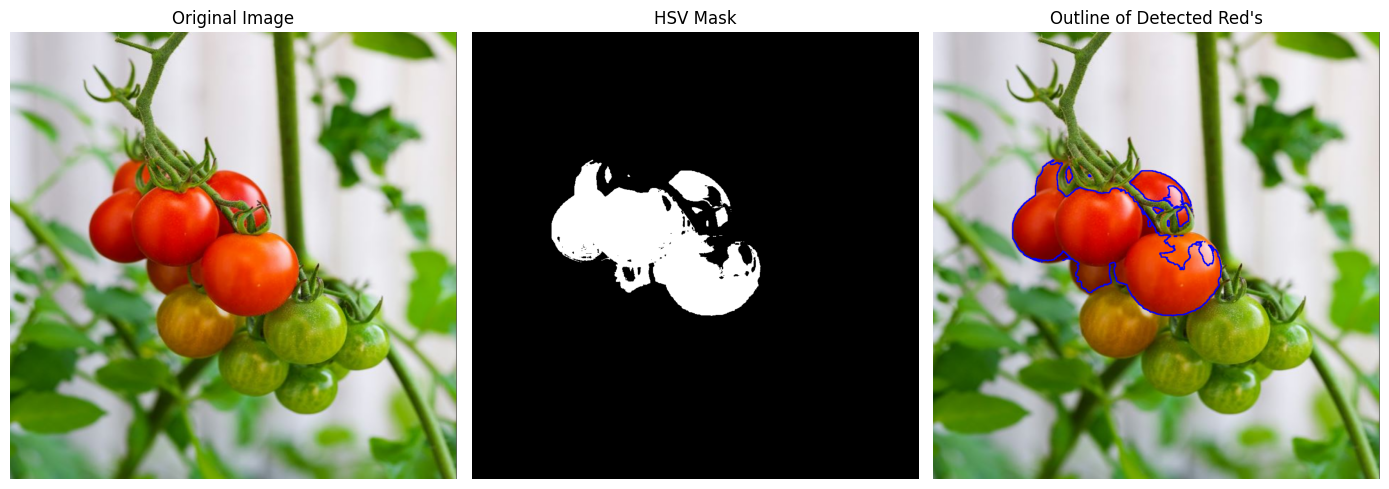

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import os

# Use some exception handling to observe best practices
try:
# Open and resize image to height = 1000 width = 1000
  width_height = (1000, 1000)
  img = cv2.imread('/content/Tomatoes_Ripe.jpg')
  img = cv2.resize(img, width_height, interpolation=cv2.INTER_AREA)

# Convert BGR to HSV
  hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
  original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Define HSV ranges for 'red'
# Adjust for desired red hue/saturation
#                     ([ H   S    V  ])
  lower_red = np.array([ 0, 100, 100  ])
  upper_red = np.array([ 10, 255, 255 ])
#                     ([ H    S    V  ])

# Use min/max of Hue in the HSV image to get the 'red mask'
  red_mask = cv2.inRange(hsv, lower_red, upper_red)

# Use mask to draw contours
  contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Overlay contours on a copy of the original image
  blue_outline_color = (255, 0, 0)

# Copy the image so we can display an original copy of it at the end
  blue_outline = img.copy()

# This takes the image copy and draws the contours with a line weight of 2.
# Change the last number and the outline color variable to see how it changes the output
# The -1 indicates that all of the contours will be drawn, other funtions of this argument
# can be used to draw contours at specific locations on the image
  cv2.drawContours(blue_outline, contours, -1, blue_outline_color, 2)
  outline_reds = cv2.cvtColor(blue_outline, cv2.COLOR_BGR2RGB)

# Show original image, mask, and outline of red images in 3 x 3 subplot
  fig = plt.figure(figsize=(14, 8))
  ax1 = fig.add_subplot(1, 3, 1)
  ax2 = fig.add_subplot(1, 3, 2)
  ax3 = fig.add_subplot(1, 3, 3)
  ax1.imshow(original_img), ax1.set_title('Original Image'), ax1.axis('off')
  ax2.imshow(red_mask, cmap='gray'), ax2.set_title('HSV Mask'), ax2.axis('off')
  ax3.imshow(outline_reds), ax3.set_title('Outline of Detected Red\'s'), ax3.axis('off')
  plt.tight_layout()
  plt.show()

# Just in case image isnt processed correctly tell us why
except Exception as e:
  print(f'Error processing {img}')

---
##***Download the OOO_BLUUUE.zip file from the assignment page.***
##***UNZIP IT BEFORE YOU UPLOAD IT TO YOUR GOOGLE DRIVE!!***
##***Make sure to upload the FOLDER to your drive and not just the individual files***
---
### The previous code showed a method for identifying red pixels in an image.
### For the final section of the project, modify the code below to:
###1.   Read all of the images in the folder
###2.   Outline all ***BLUE*** objects in the image
###3.   Saves all analyzed images in the working directory folder
---
#### Common HSV Color Map:
>Hue (H): 0-179 (Represents color position on the color wheel)
* Red: 0-10
* Yellow: 20-30
* Green: 60-70
* Cyan: 90-100
* Blue: 120-130
* Magenta: 150-160

>Saturation (S): 0-255 (Represents color intensity/purity)
* 0: Grayscale
* 255: Full color intensity

>Value (V): 0-255 (Represents brightness)
* 0: Black
* 255: Maximum brightness

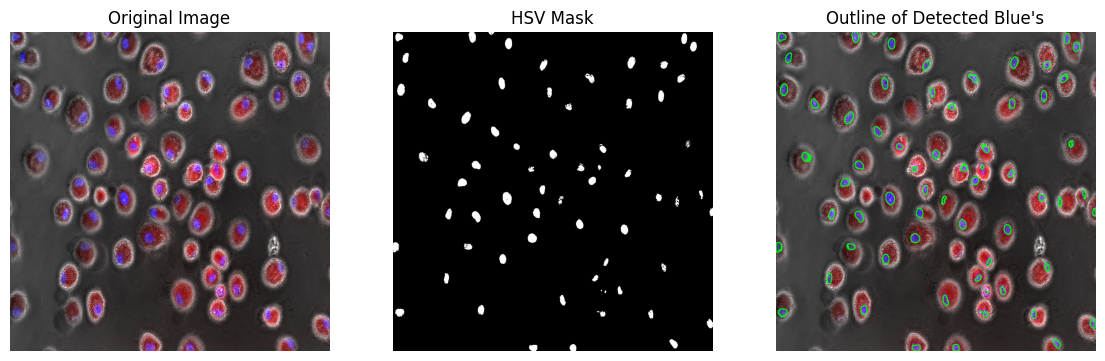

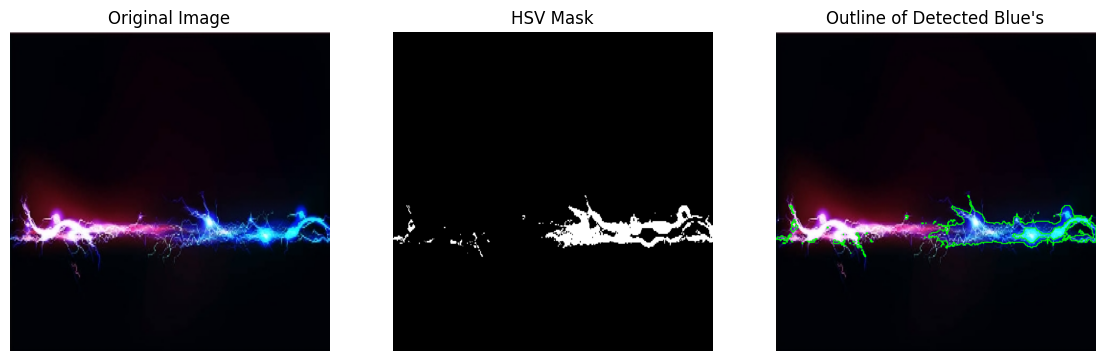

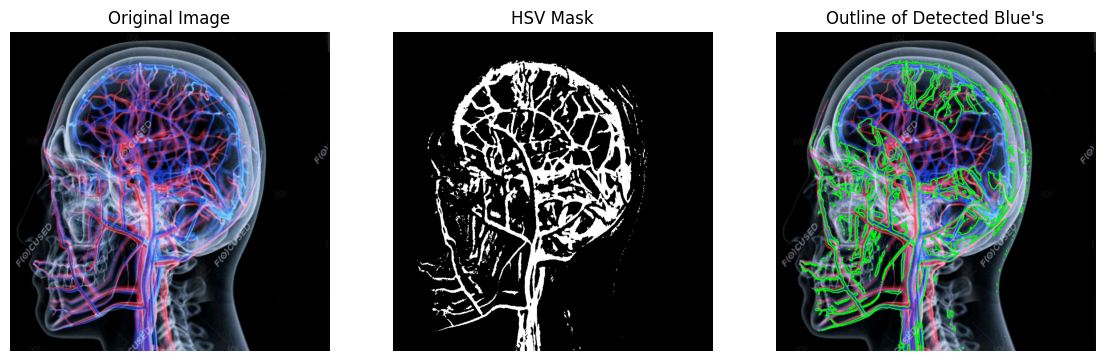

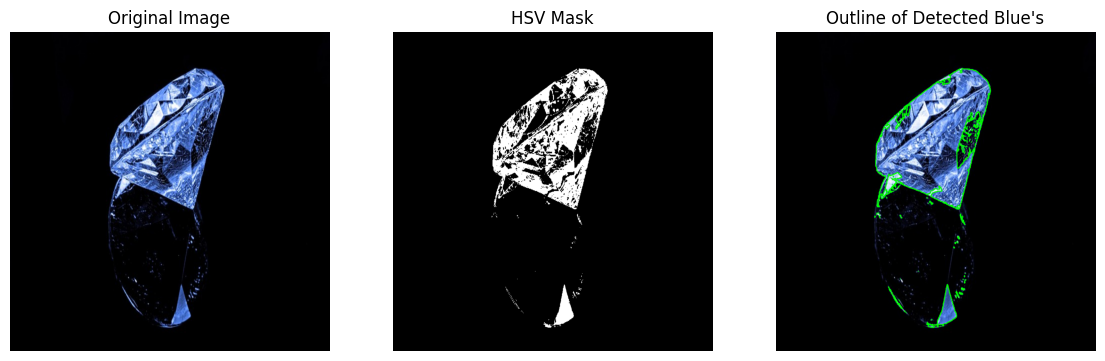

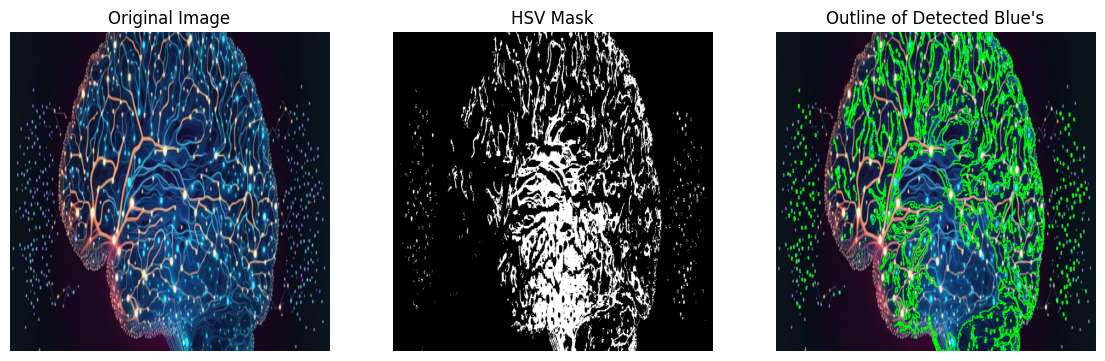

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import os

image_folder = '/content/OOO_BLUUUE'

# Resize image to height = 1000 width = 1000
width_height = (1000, 1000)

# Look through folder and analyze each image for blue colors
for image_name in os.listdir(image_folder):

  if '_Analysis' in image_name:
    continue

  # Make image path
  image_path = os.path.join(image_folder, image_name)

  try:

    # Open image
    img = cv2.imread(image_path)

    img = cv2.resize(
        img,
        width_height,
        interpolation=cv2.INTER_AREA
    )

    original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert BGR to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define HSV ranges for blue
    lower_blue = np.array([100, 100, 100])
    upper_blue = np.array([140, 255, 255])

    # Threshold HSV image to get blue mask
    blue_mask = cv2.inRange(
        hsv,
        lower_blue,
        upper_blue
    )

    # Find contours
    contours, _ = cv2.findContours(
        blue_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw green contours
    green_outline_color = (0, 255, 0)

    green_outline = img.copy()

    cv2.drawContours(
        green_outline,
        contours,
        -1,
        green_outline_color,
        2
    )

    outline_blues = cv2.cvtColor(
        green_outline,
        cv2.COLOR_BGR2RGB
    )

    # Show original image, mask, and result
    fig = plt.figure(figsize=(14, 8))

    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3)

    ax1.imshow(original_img)
    ax1.set_title('Original Image')
    ax1.axis('off')

    ax2.imshow(blue_mask, cmap='gray')
    ax2.set_title('HSV Mask')
    ax2.axis('off')

    ax3.imshow(outline_blues)
    ax3.set_title("Outline of Detected Blue's")
    ax3.axis('off')

    # Create filename for analyzed image
    analyzed_image = image_name.split(".")
    analyzed_image = f'{analyzed_image[0]}_Analysis.jpg'

    # Save analyzed image
    plt.savefig(
        os.path.join(
            image_folder,
            analyzed_image
        )
    )

    # IMPORTANT: display it so it appears in your final PDF
    plt.show()

    plt.close()

  except Exception as e:
    print(f'Error processing {image_name}: {e}')